# CA / RL Real-Capital Backtest

?? notebook ??? Track B ?????? CA / RL ???????? action library ????????????????

- ????? **CA / RL ?? action ??????**?????????????
- `Cash` ??? flat??????????????????? `0.0`?
- `MODEL_INITIAL_CAPITAL` ???????? holdout ?????????
- `EXIT_ON_BANKRUPTCY=True` ???????????????


In [1]:
from __future__ import annotations

from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

CURRENT_DIR = Path.cwd()
NOTEBOOK_DIR = CURRENT_DIR if (CURRENT_DIR / "cluster_action_backtest.py").exists() else CURRENT_DIR / "Final_Project" / "track_b"
if not (NOTEBOOK_DIR / "cluster_action_backtest.py").exists():
    raise FileNotFoundError("Could not locate Final_Project/track_b from the current working directory.")

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from cluster_action_backtest import (
    ActionBacktestConfig,
    build_action_library_from_templates,
    build_hmm_baseline_experiment_result,
    build_model_ranking_tables as build_ca_ranking_tables,
    evaluate_model_cluster_actions,
    load_tradable_returns,
)
from experiment_cache import DEFAULT_MODELS_DIR, run_experiment_with_cache
from experiment_presets import (
    build_architecture_runners,
    build_default_experiment_setups,
)
from rl_backtest_agent import (
    QLearningAgentConfig,
    build_model_ranking_tables as build_rl_ranking_tables,
    evaluate_model_with_q_learning,
)
from encoder_only_transformer import HMMLEARN_AVAILABLE, load_market_and_macro

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 220)


In [2]:
DATA_DIR = NOTEBOOK_DIR.parent / "data"
MODELS_DIR = Path(DEFAULT_MODELS_DIR)
OUTPUT_DIR = NOTEBOOK_DIR / "results" / "manual_cash_portfolio_backtest"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_CLUSTER_COUNT = 4
ARCHITECTURES = None  # None = all cached Track B architectures
INCLUDE_CA = True
INCLUDE_RL = True
INCLUDE_HMM_BASELINE = True

TRADABLE_ASSETS = ("SPY", "TLT", "GLD", "Cash")
MODEL_INITIAL_CAPITAL = 10_000.0
CASH_PROXY_SOURCE = "FLAT"
TRANSACTION_COST = 0.001
EXECUTION_LAG = 1
EXIT_ON_BANKRUPTCY = True

OBJECTIVE = "sharpe"
VALIDATION_RATIO = 0.20
TEST_RATIO = 0.10
MAPPING_FIT_SPLIT = "train"
ALLOW_ACTION_REUSE = False

ACTION_TEMPLATES = {
    "recession": {"SPY": 0.00, "TLT": 0.10, "GLD": 0.20, "Cash": 0.70},
    "defensive": {"SPY": 0.10, "TLT": 0.40, "GLD": 0.25, "Cash": 0.25},
    "rebound": {"SPY": 0.50, "TLT": 0.20, "GLD": 0.20, "Cash": 0.10},
    "aggressive": {"SPY": 0.80, "TLT": 0.10, "GLD": 0.10, "Cash": 0.00},
}

RL_EPISODES = 50
RL_LEARNING_RATE = 0.10
RL_DISCOUNT_FACTOR = 0.95
RL_EPSILON_START = 0.30
RL_EPSILON_END = 0.02
RL_EPSILON_DECAY = 0.985
RL_EVAL_INTERVAL = 1
RL_REWARD_SCALE = 1.0
RL_RANDOM_STATE = 42
RL_INCLUDE_PREVIOUS_ACTION = True

print("architectures         =", ARCHITECTURES if ARCHITECTURES is not None else "ALL")
print("include_ca            =", INCLUDE_CA)
print("include_rl            =", INCLUDE_RL)
print("target_clusters       =", TARGET_CLUSTER_COUNT)
print("initial_capital       =", MODEL_INITIAL_CAPITAL)
print("cash_proxy_source     =", CASH_PROXY_SOURCE)
print("execution_lag         =", EXECUTION_LAG)
print("exit_on_bankruptcy    =", EXIT_ON_BANKRUPTCY)
print("action_count          =", len(ACTION_TEMPLATES))


architectures         = ALL
include_ca            = True
include_rl            = True
target_clusters       = 4
initial_capital       = 10000.0
cash_proxy_source     = FLAT
execution_lag         = 1
exit_on_bankruptcy    = True
action_count          = 4


In [3]:
action_library = build_action_library_from_templates(
    action_templates=ACTION_TEMPLATES,
    tradable_assets=TRADABLE_ASSETS,
)
action_library_df = pd.DataFrame(action_library).T
action_library_df.index.name = "action"

if INCLUDE_CA and not ALLOW_ACTION_REUSE and len(action_library) < TARGET_CLUSTER_COUNT:
    raise ValueError(
        "CA requires len(action_library) >= TARGET_CLUSTER_COUNT when ALLOW_ACTION_REUSE=False. "
        f"Got {len(action_library)} actions for {TARGET_CLUSTER_COUNT} clusters."
    )

backtest_config = ActionBacktestConfig(
    tradable_assets=TRADABLE_ASSETS,
    initial_capital=MODEL_INITIAL_CAPITAL,
    transaction_cost=TRANSACTION_COST,
    execution_lag=EXECUTION_LAG,
    validation_ratio=VALIDATION_RATIO,
    test_ratio=TEST_RATIO,
    objective=OBJECTIVE,
    mapping_fit_split=MAPPING_FIT_SPLIT,
    allow_action_reuse=ALLOW_ACTION_REUSE,
    cash_proxy_source=CASH_PROXY_SOURCE,
    exit_on_bankruptcy=EXIT_ON_BANKRUPTCY,
)
agent_config = QLearningAgentConfig(
    episodes=RL_EPISODES,
    learning_rate=RL_LEARNING_RATE,
    discount_factor=RL_DISCOUNT_FACTOR,
    epsilon_start=RL_EPSILON_START,
    epsilon_end=RL_EPSILON_END,
    epsilon_decay=RL_EPSILON_DECAY,
    include_previous_action=RL_INCLUDE_PREVIOUS_ACTION,
    eval_interval=RL_EVAL_INTERVAL,
    reward_scale=RL_REWARD_SCALE,
    random_state=RL_RANDOM_STATE,
)

display(action_library_df)


,SPY,TLT,GLD,Cash
action,,,,
recession,0.0,0.1,0.20,0.70
defensive,0.1,0.4,0.25,0.25
rebound,0.5,0.2,0.20,0.10
aggressive,0.8,0.1,0.10,0.00


In [4]:
runners = build_architecture_runners()
experiment_setups = build_default_experiment_setups(
    data_dir=DATA_DIR,
    hmm_enabled=False,
    target_cluster_count=TARGET_CLUSTER_COUNT,
    device="auto",
)
if ARCHITECTURES is not None:
    requested = set(ARCHITECTURES)
    experiment_setups = [setup for setup in experiment_setups if setup["architecture"] in requested]

if not experiment_setups:
    raise ValueError("No experiment setups selected. Check ARCHITECTURES.")

train_ratio = backtest_config.train_ratio
experiment_setups = [
    {
        **setup,
        "training_config": replace(
            setup["training_config"],
            train_ratio=train_ratio,
            validation_ratio=VALIDATION_RATIO,
            test_ratio=TEST_RATIO,
            random_state=RL_RANDOM_STATE,
        ),
    }
    for setup in experiment_setups
]

returns_data_config = experiment_setups[0]["data_config"]
raw_market_data, _ = load_market_and_macro(returns_data_config)
asset_returns = load_tradable_returns(
    data_config=returns_data_config,
    tradable_assets=backtest_config.tradable_assets,
    cash_proxy_source=backtest_config.cash_proxy_source,
    cash_asset_name=backtest_config.cash_asset_name,
)

experiment_results = []
for setup in experiment_setups:
    print(f"[cache] loading {setup['name']} ({setup['architecture']})")
    experiment_result = run_experiment_with_cache(
        runner=runners[setup["architecture"]],
        experiment_name=setup["name"],
        data_config=setup["data_config"],
        model_config=setup["model_config"],
        training_config=setup["training_config"],
        clustering_config=setup["clustering_config"],
        hmm_config=setup["hmm_config"],
        models_dir=MODELS_DIR,
        verbose=True,
    )
    experiment_results.append(experiment_result)

if INCLUDE_HMM_BASELINE and HMMLEARN_AVAILABLE:
    hmm_result = build_hmm_baseline_experiment_result(
        data_config=returns_data_config,
        target_cluster_count=TARGET_CLUSTER_COUNT,
        random_state=RL_RANDOM_STATE,
    )
    if hmm_result is not None:
        experiment_results.append(hmm_result)

manifest_df = pd.DataFrame([
    {
        "experiment_name": result["experiment_name"],
        "architecture": result["summary"].get("architecture"),
    }
    for result in experiment_results
])
display(manifest_df)
print("cash_mean_daily_ret   =", round(float(asset_returns["Cash"].mean()), 8))


[cache] loading encoder_only (encoder_only)
[cache] loaded encoder_only from F:\Documents\GitHub\CU_Quant_Trade\Final_Project\track_b\models\encoder_only__857cf1703a70ba34
[cache] loading encoder_only_market_tuples (encoder_only_market_tuples)
[cache] loaded encoder_only_market_tuples from F:\Documents\GitHub\CU_Quant_Trade\Final_Project\track_b\models\encoder_only_market_tuples__acbc05d109bad341
[cache] loading patchtst (patchtst)
[cache] loaded patchtst from F:\Documents\GitHub\CU_Quant_Trade\Final_Project\track_b\models\patchtst__3aabc1c9a16bac9c
[cache] loading pathformer (pathformer)
[cache] loaded pathformer from F:\Documents\GitHub\CU_Quant_Trade\Final_Project\track_b\models\pathformer__5d46f0faafa94aaf
[cache] loading cls_token_transformer (cls_token_transformer)
[cache] loaded cls_token_transformer from F:\Documents\GitHub\CU_Quant_Trade\Final_Project\track_b\models\cls_token_transformer__83d13717b78ff2dd
[cache] loading conv_transformer (conv_transformer)
[cache] loaded conv_

,experiment_name,architecture
0,encoder_only,encoder_only
1,encoder_only_market_tuples,encoder_only_market_tuples
2,patchtst,patchtst
3,pathformer,pathformer
4,cls_token_transformer,encoder_only
5,conv_transformer,conv_transformer
6,tcn_transformer,tcn_transformer
7,mae_transformer,mae_transformer
8,pure_rnn,pure_rnn
9,rnn_lstm_hybrid,rnn_lstm_hybrid


cash_mean_daily_ret   = 0.0


In [5]:
def summarize_family_results(evaluation_results: list[dict], family_label: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    nav_frames = []
    for result in evaluation_results:
        summary = dict(result["summary"])
        combined_backtest = result["combined_backtest_result"]
        nav = combined_backtest["portfolio_nav"].rename(f"{family_label}:{summary['experiment_name']}")
        nav_frames.append(nav)

        row = {
            "family": family_label,
            "experiment_name": summary["experiment_name"],
            "source_experiment": summary.get("source_experiment", summary["experiment_name"]),
            "architecture": summary.get("architecture"),
            "initial_capital": float(backtest_config.initial_capital),
            "combined_final_nav": float(combined_backtest["portfolio_nav"].iloc[-1]),
            "combined_profit_loss": float(combined_backtest["portfolio_nav"].iloc[-1] - backtest_config.initial_capital),
            "combined_bankruptcy_triggered": bool(combined_backtest.get("bankruptcy_triggered", False)),
            "combined_bankruptcy_date": (
                pd.Timestamp(combined_backtest.get("bankruptcy_date")).strftime("%Y-%m-%d")
                if pd.notna(combined_backtest.get("bankruptcy_date"))
                else None
            ),
            "best_mapping": summary.get("best_mapping"),
            "best_episode": summary.get("best_episode"),
        }
        for key, value in summary.items():
            if key.startswith("combined_"):
                row[key] = value
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    if summary_df.empty:
        return summary_df, pd.DataFrame()
    summary_df = summary_df.sort_values(["combined_sharpe", "combined_annual_return"], ascending=[False, False]).reset_index(drop=True)
    nav_df = pd.concat(nav_frames, axis=1) if nav_frames else pd.DataFrame()
    return summary_df, nav_df


In [6]:
ca_results = []
ca_combined_ranking = pd.DataFrame()
ca_summary_df = pd.DataFrame()
ca_nav_df = pd.DataFrame()

if INCLUDE_CA:
    for experiment_result in experiment_results:
        print(f"[CA] evaluating {experiment_result['experiment_name']}")
        ca_results.append(
            evaluate_model_cluster_actions(
                experiment_result=experiment_result,
                asset_returns=asset_returns,
                action_library=action_library,
                config=backtest_config,
            )
        )
    _, _, ca_combined_ranking = build_ca_ranking_tables(ca_results, backtest_config.objective)
    ca_summary_df, ca_nav_df = summarize_family_results(ca_results, "CA")
    display(ca_summary_df[[
        "family",
        "experiment_name",
        "architecture",
        "combined_sharpe",
        "combined_annual_return",
        "combined_final_nav",
        "combined_profit_loss",
        "combined_max_drawdown",
        "combined_total_turnover",
        "combined_bankruptcy_triggered",
        "best_mapping",
    ]])


[CA] evaluating encoder_only
[CA] evaluating encoder_only_market_tuples
[CA] evaluating patchtst
[CA] evaluating pathformer
[CA] evaluating cls_token_transformer
[CA] evaluating conv_transformer
[CA] evaluating tcn_transformer
[CA] evaluating mae_transformer
[CA] evaluating pure_rnn
[CA] evaluating rnn_lstm_hybrid
[CA] evaluating rnn_autoencoder
[CA] evaluating lstm_autoencoder
[CA] evaluating transformer_autoencoder
[CA] evaluating vae
[CA] evaluating kmeans_baseline
[CA] evaluating pca_kmeans_baseline
[CA] evaluating hmm_baseline


,family,experiment_name,architecture,combined_sharpe,combined_annual_return,combined_final_nav,combined_profit_loss,combined_max_drawdown,combined_total_turnover,combined_bankruptcy_triggered,best_mapping
0,CA,tcn_transformer,tcn_transformer,0.996778,0.134046,14848.985527,4848.985527,-0.084939,41.2,False,0->rebound; 1->aggressive; 2->defensive; 3->re...
1,CA,cls_token_transformer,encoder_only,0.838507,0.102661,13595.330180,3595.330180,-0.086545,42.6,False,0->rebound; 1->recession; 2->aggressive; 3->de...
2,CA,conv_transformer,conv_transformer,0.739034,0.108059,13805.575119,3805.575119,-0.085075,35.9,False,0->aggressive; 1->recession; 2->defensive; 3->...
3,CA,encoder_only,encoder_only,0.620692,0.117847,14192.495839,4192.495839,-0.150058,15.6,False,0->rebound; 1->aggressive; 2->recession; 3->de...
4,CA,rnn_autoencoder,rnn_autoencoder,0.507458,0.088326,13047.525010,3047.525010,-0.080073,219.6,False,0->recession; 1->rebound; 2->aggressive; 3->de...
5,CA,mae_transformer,mae_transformer,0.468251,0.077575,12646.724802,2646.724802,-0.046981,125.6,False,0->recession; 1->rebound; 2->aggressive; 3->de...
6,CA,transformer_autoencoder,transformer_autoencoder,0.438529,0.089118,13077.393041,3077.393041,-0.092584,52.0,False,0->defensive; 1->recession; 2->aggressive; 3->...
7,CA,lstm_autoencoder,lstm_autoencoder,0.419672,0.086022,12960.910099,2960.910099,-0.119676,46.0,False,0->defensive; 1->rebound; 2->recession; 3->agg...
8,CA,rnn_lstm_hybrid,rnn_lstm_hybrid,0.401578,0.081228,12781.945575,2781.945575,-0.092188,55.5,False,0->aggressive; 1->defensive; 2->rebound; 3->re...
9,CA,encoder_only_market_tuples,encoder_only_market_tuples,0.336131,0.062640,12103.958181,2103.958181,-0.042505,1.0,False,0->rebound; 1->recession; 2->aggressive; 3->de...


In [7]:
rl_results = []
rl_combined_ranking = pd.DataFrame()
rl_summary_df = pd.DataFrame()
rl_nav_df = pd.DataFrame()

if INCLUDE_RL:
    for experiment_result in experiment_results:
        print(f"[RL] evaluating {experiment_result['experiment_name']}")
        rl_results.append(
            evaluate_model_with_q_learning(
                experiment_result=experiment_result,
                asset_returns=asset_returns,
                action_library=action_library,
                backtest_config=backtest_config,
                agent_config=agent_config,
                pretrained_policy=None,
            )
        )
    _, _, rl_combined_ranking = build_rl_ranking_tables(rl_results, backtest_config.objective)
    rl_summary_df, rl_nav_df = summarize_family_results(rl_results, "RL")
    display(rl_summary_df[[
        "family",
        "experiment_name",
        "architecture",
        "combined_sharpe",
        "combined_annual_return",
        "combined_final_nav",
        "combined_profit_loss",
        "combined_max_drawdown",
        "combined_total_turnover",
        "combined_bankruptcy_triggered",
        "best_episode",
    ]])


[RL] evaluating encoder_only
[RL] evaluating encoder_only_market_tuples
[RL] evaluating patchtst
[RL] evaluating pathformer
[RL] evaluating cls_token_transformer
[RL] evaluating conv_transformer
[RL] evaluating tcn_transformer
[RL] evaluating mae_transformer
[RL] evaluating pure_rnn
[RL] evaluating rnn_lstm_hybrid
[RL] evaluating rnn_autoencoder
[RL] evaluating lstm_autoencoder
[RL] evaluating transformer_autoencoder
[RL] evaluating vae
[RL] evaluating kmeans_baseline
[RL] evaluating pca_kmeans_baseline
[RL] evaluating hmm_baseline


,family,experiment_name,architecture,combined_sharpe,combined_annual_return,combined_final_nav,combined_profit_loss,combined_max_drawdown,combined_total_turnover,combined_bankruptcy_triggered,best_episode
0,RL,lstm_autoencoder__q_learning,lstm_autoencoder+q_learning,1.206758,0.162428,16048.565278,6048.565278,-0.092584,7.2,False,11
1,RL,rnn_autoencoder__q_learning,rnn_autoencoder+q_learning,1.181104,0.146369,15362.035137,5362.035137,-0.092507,22.4,False,26
2,RL,kmeans_baseline__q_learning,kmeans_baseline+q_learning,1.152410,0.160682,15972.945270,5972.945270,-0.092584,2.2,False,23
3,RL,pca_kmeans_baseline__q_learning,pca_kmeans_baseline+q_learning,1.152410,0.160682,15972.945270,5972.945270,-0.092584,2.2,False,5
4,RL,hmm_baseline__q_learning,hmm_baseline+q_learning,1.106823,0.154801,15719.956224,5719.956224,-0.092584,10.6,False,4
5,RL,transformer_autoencoder__q_learning,transformer_autoencoder+q_learning,1.067423,0.119681,14265.814999,4265.814999,-0.084939,54.8,False,28
6,RL,conv_transformer__q_learning,conv_transformer+q_learning,1.054706,0.146918,15385.150004,5385.150004,-0.095249,29.8,False,15
7,RL,tcn_transformer__q_learning,tcn_transformer+q_learning,0.947545,0.139062,15056.375223,5056.375223,-0.086421,42.4,False,35
8,RL,cls_token_transformer__q_learning,encoder_only+q_learning,0.713531,0.089373,13087.032901,3087.032901,-0.076932,30.4,False,20
9,RL,mae_transformer__q_learning,mae_transformer+q_learning,0.674010,0.105010,13686.541557,3686.541557,-0.104077,6.1,False,44


,family,experiment_name,architecture,combined_sharpe,combined_annual_return,combined_final_nav,combined_profit_loss,combined_max_drawdown,combined_total_turnover,combined_bankruptcy_triggered,best_mapping,best_episode
0,RL,lstm_autoencoder__q_learning,lstm_autoencoder+q_learning,1.206758,0.162428,16048.565278,6048.565278,-0.092584,7.2,False,"q_learning_policy(episodes=50,alpha=0.100,gamm...",11
1,RL,rnn_autoencoder__q_learning,rnn_autoencoder+q_learning,1.181104,0.146369,15362.035137,5362.035137,-0.092507,22.4,False,"q_learning_policy(episodes=50,alpha=0.100,gamm...",26
2,RL,kmeans_baseline__q_learning,kmeans_baseline+q_learning,1.152410,0.160682,15972.945270,5972.945270,-0.092584,2.2,False,"q_learning_policy(episodes=50,alpha=0.100,gamm...",23
3,RL,pca_kmeans_baseline__q_learning,pca_kmeans_baseline+q_learning,1.152410,0.160682,15972.945270,5972.945270,-0.092584,2.2,False,"q_learning_policy(episodes=50,alpha=0.100,gamm...",5
4,RL,hmm_baseline__q_learning,hmm_baseline+q_learning,1.106823,0.154801,15719.956224,5719.956224,-0.092584,10.6,False,"q_learning_policy(episodes=50,alpha=0.100,gamm...",4
5,RL,transformer_autoencoder__q_learning,transformer_autoencoder+q_learning,1.067423,0.119681,14265.814999,4265.814999,-0.084939,54.8,False,"q_learning_policy(episodes=50,alpha=0.100,gamm...",28
6,RL,conv_transformer__q_learning,conv_transformer+q_learning,1.054706,0.146918,15385.150004,5385.150004,-0.095249,29.8,False,"q_learning_policy(episodes=50,alpha=0.100,gamm...",15
7,CA,tcn_transformer,tcn_transformer,0.996778,0.134046,14848.985527,4848.985527,-0.084939,41.2,False,0->rebound; 1->aggressive; 2->defensive; 3->re...,None
8,RL,tcn_transformer__q_learning,tcn_transformer+q_learning,0.947545,0.139062,15056.375223,5056.375223,-0.086421,42.4,False,"q_learning_policy(episodes=50,alpha=0.100,gamm...",35
9,CA,cls_token_transformer,encoder_only,0.838507,0.102661,13595.330180,3595.330180,-0.086545,42.6,False,0->rebound; 1->recession; 2->aggressive; 3->de...,None


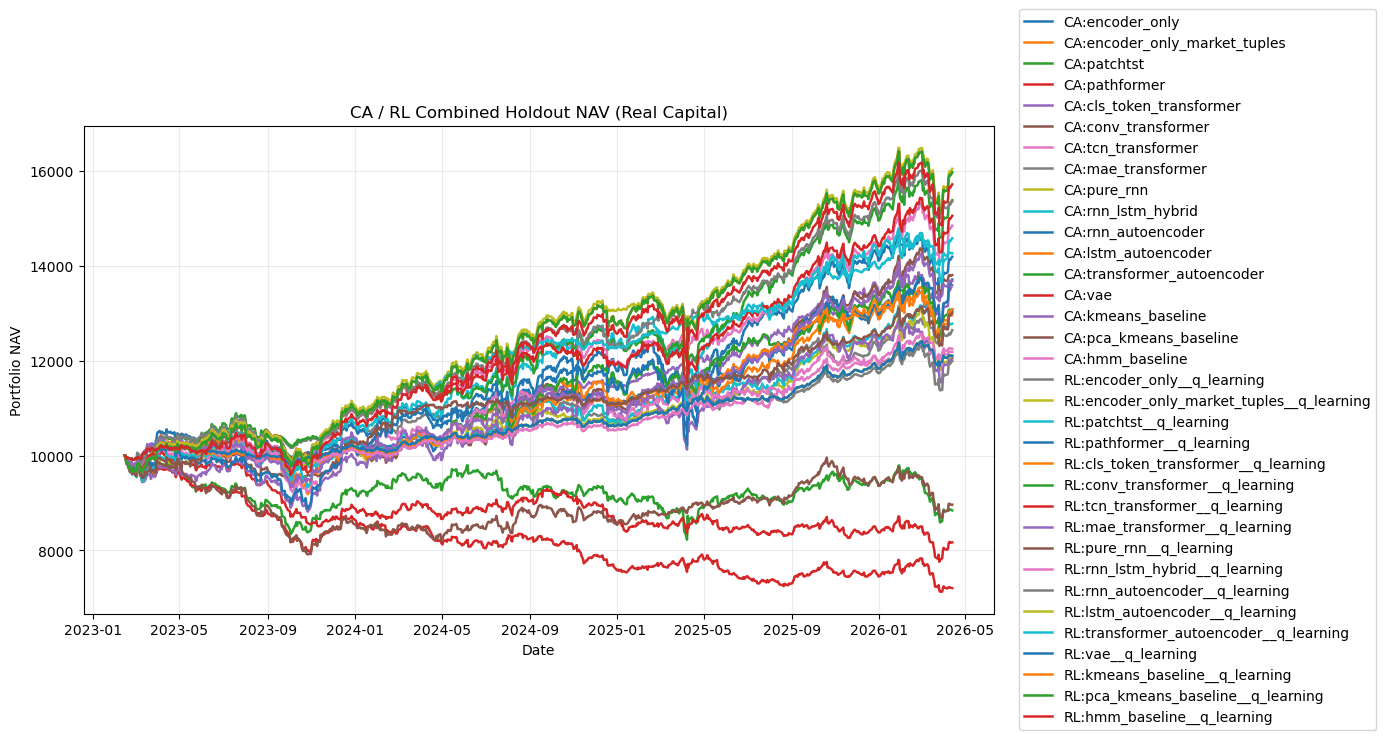

In [8]:
all_summary_frames = [frame for frame in [ca_summary_df, rl_summary_df] if not frame.empty]
all_nav_frames = [frame for frame in [ca_nav_df, rl_nav_df] if not frame.empty]

combined_summary_df = pd.concat(all_summary_frames, ignore_index=True) if all_summary_frames else pd.DataFrame()
combined_nav_df = pd.concat(all_nav_frames, axis=1) if all_nav_frames else pd.DataFrame()

if not combined_summary_df.empty:
    combined_summary_df = combined_summary_df.sort_values(["combined_sharpe", "combined_annual_return"], ascending=[False, False]).reset_index(drop=True)
    display(combined_summary_df[[
        "family",
        "experiment_name",
        "architecture",
        "combined_sharpe",
        "combined_annual_return",
        "combined_final_nav",
        "combined_profit_loss",
        "combined_max_drawdown",
        "combined_total_turnover",
        "combined_bankruptcy_triggered",
        "best_mapping",
        "best_episode",
    ]])

if not combined_nav_df.empty:
    fig, ax = plt.subplots(figsize=(14, 7))
    for column in combined_nav_df.columns:
        ax.plot(combined_nav_df.index, combined_nav_df[column], label=column, linewidth=1.8)
    ax.set_title("CA / RL Combined Holdout NAV (Real Capital)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Portfolio NAV")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()


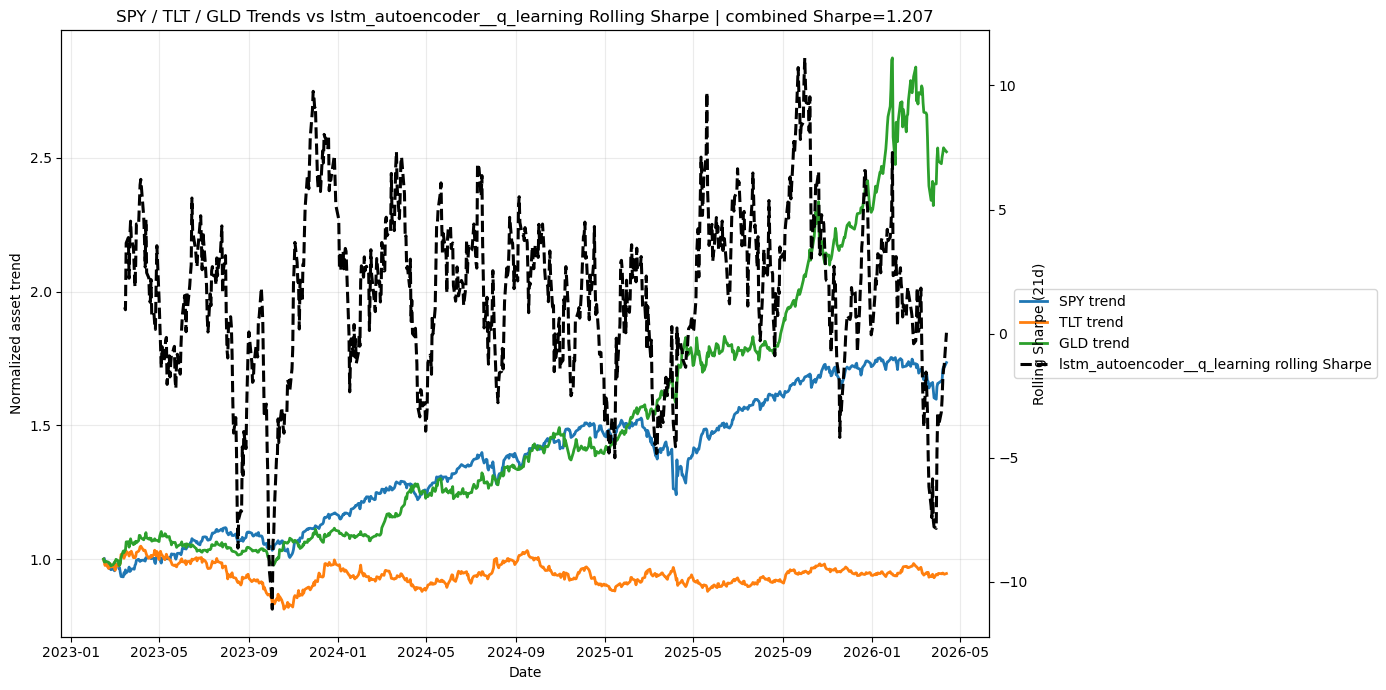

In [9]:
SHARPE_TREND_MODEL = "lstm_autoencoder__q_learning"
SHARPE_TREND_ASSETS = ["SPY", "TLT", "GLD"]
ROLLING_SHARPE_WINDOW = 21

selected_rl_result = next(
    (result for result in rl_results if result["summary"]["experiment_name"] == SHARPE_TREND_MODEL),
    None,
)

if selected_rl_result is None:
    print(f"{SHARPE_TREND_MODEL} not found in rl_results. Run INCLUDE_RL=True and keep the model in ARCHITECTURES.")
else:
    combined_backtest = selected_rl_result["combined_backtest_result"]
    holdout_index = combined_backtest["portfolio_returns"].index
    market_trend_frame = raw_market_data.loc[
        (raw_market_data.index >= holdout_index.min()) & (raw_market_data.index <= holdout_index.max()),
        SHARPE_TREND_ASSETS,
    ].copy()
    asset_trend_nav = market_trend_frame.div(market_trend_frame.iloc[0])

    portfolio_returns = combined_backtest["portfolio_returns"].fillna(0.0)
    combined_rf_annual = float(selected_rl_result["summary"].get("combined_risk_free_rate", 0.0))
    combined_rf_daily = (1.0 + combined_rf_annual) ** (1.0 / backtest_config.annualization_factor) - 1.0
    excess_returns = portfolio_returns - combined_rf_daily
    rolling_mean = excess_returns.rolling(ROLLING_SHARPE_WINDOW).mean()
    rolling_std = excess_returns.rolling(ROLLING_SHARPE_WINDOW).std(ddof=0)
    rolling_sharpe = ((rolling_mean / rolling_std) * np.sqrt(backtest_config.annualization_factor)).where(rolling_std > 0)

    fig, ax_left = plt.subplots(figsize=(14, 7))
    for asset_name in SHARPE_TREND_ASSETS:
        ax_left.plot(asset_trend_nav.index, asset_trend_nav[asset_name], linewidth=2, label=f"{asset_name} trend")
    ax_left.set_xlabel("Date")
    ax_left.set_ylabel("Normalized asset trend")
    ax_left.grid(True, alpha=0.25)

    ax_right = ax_left.twinx()
    ax_right.plot(rolling_sharpe.index, rolling_sharpe, color="black", linestyle="--", linewidth=2.2, label=f"{SHARPE_TREND_MODEL} rolling Sharpe")
    ax_right.set_ylabel(f"Rolling Sharpe ({ROLLING_SHARPE_WINDOW}d)")

    combined_sharpe_value = float(selected_rl_result["summary"].get("combined_sharpe", float("nan")))
    ax_left.set_title(
        f"SPY / TLT / GLD Trends vs {SHARPE_TREND_MODEL} Rolling Sharpe | combined Sharpe={combined_sharpe_value:.3f}"
    )

    handles_left, labels_left = ax_left.get_legend_handles_labels()
    handles_right, labels_right = ax_right.get_legend_handles_labels()
    ax_left.legend(handles_left + handles_right, labels_left + labels_right, loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()


In [10]:
action_library_df.to_csv(OUTPUT_DIR / "action_library.csv")
manifest_df.to_csv(OUTPUT_DIR / "experiment_manifest.csv", index=False)

if not ca_combined_ranking.empty:
    ca_combined_ranking.to_csv(OUTPUT_DIR / "ca_combined_ranking.csv", index=False)
if not rl_combined_ranking.empty:
    rl_combined_ranking.to_csv(OUTPUT_DIR / "rl_combined_ranking.csv", index=False)
if not combined_summary_df.empty:
    combined_summary_df.to_csv(OUTPUT_DIR / "combined_money_summary.csv", index=False)
if not combined_nav_df.empty:
    combined_nav_df.to_csv(OUTPUT_DIR / "combined_holdout_nav.csv")

for family_label, evaluation_results in [("ca", ca_results), ("rl", rl_results)]:
    family_dir = OUTPUT_DIR / family_label
    family_dir.mkdir(parents=True, exist_ok=True)
    for result in evaluation_results:
        safe_name = result["summary"]["experiment_name"].replace("/", "_").replace("\\", "_")
        combined_backtest = result["combined_backtest_result"]
        export_df = pd.DataFrame({
            "portfolio_nav": combined_backtest["portfolio_nav"],
            "portfolio_return": combined_backtest["portfolio_returns"],
            "turnover": combined_backtest["turnover"],
        })
        if "action_series" in combined_backtest:
            export_df["action"] = combined_backtest["action_series"]
        if "cluster_series" in combined_backtest:
            export_df["cluster"] = combined_backtest["cluster_series"]
        export_df.to_csv(family_dir / f"{safe_name}_combined_backtest.csv")

print(f"saved outputs under {OUTPUT_DIR}")


saved outputs under f:\Documents\GitHub\CU_Quant_Trade\Final_Project\track_b\results\manual_cash_portfolio_backtest
